# arxiv.org/pdf/2101.01258 WSe2/WS2 #

## 计算单粒子能带H0 ##

In [272]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm as tqdm
from quspin.basis import spinless_fermion_basis_1d
from quspin.operators import hamiltonian
from quspin.basis import spinless_fermion_basis_general
from quspin.tools.block_tools import block_diag_hamiltonian
import math as math
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh
import time

In [273]:
# 转角 (unit in rad)
theta = np.radians(1.38)

# MoTe2晶格常数 (unit in Angstrom)
a0 = 3.32 

# moire晶格常数 (unit in Angstrom)
aM = a0 / (2 * np.sin(theta / 2)) 

#原胞面积
A_cell= np.sqrt(3)/2 * aM**2 #unit in Angstrom^2

# 倒格矢量长度 (unit in Angstrom^-1)
bM = 4*np.pi/(np.sqrt(3)*aM) 

# 所有倒格矢量
angles = np.array([0, 1*np.pi/3, 2*np.pi/3, 3*np.pi/3, 4*np.pi/3, 5*np.pi/3]) 
b = bM * np.stack([np.cos(angles), np.sin(angles)], axis=1) 

# moire周期势V和psi （V unit in eV, psi unit in rad）
V = 8e-3
psi = np.radians(-89.6) 

#平面波截断阶数
Nbloch = 5

# hbar^2/2m* (unit in eV·Angstrom^+2) 
#m_star = 0.43 #有效质量
#h2m = 3.8099 / m_star 
h2m = 0.495*a0**2 #(https://arxiv.org/pdf/2101.01258)

# 隧穿幅度 （unit in eV）
w = -8.5e-3 

#高对称点晶格动量 K_t 对应 K_+ ， K_b 对应 K_-
Kt = bM/np.sqrt(3) * np.stack([-np.cos(np.pi/6), -np.sin(np.pi/6)], axis=0) 
Kb = bM/np.sqrt(3) * np.stack([-np.cos(np.pi/6), +np.sin(np.pi/6)], axis=0) 

100%|██████████| 35/35 [00:04<00:00,  8.11it/s]


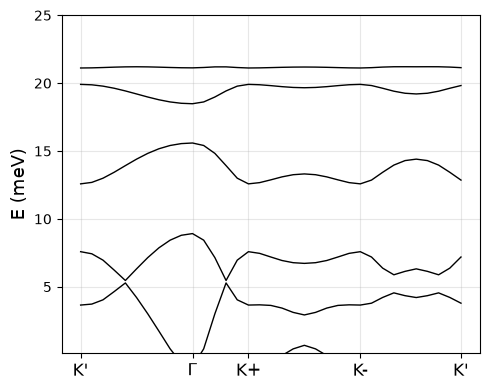

In [274]:
"""
#构造哈密顿量H0,对角项除了动量项还有上下层分别的Moire势，
#Delta = 2V sum cos(b_i cdot r + psi) = V * sum exp(1i*psi)*exp(1i*b_i * r) + exp(-1i*psi)*exp(-1i*b_i * r)
#这个含r的项的傅里叶变换给出动量空间的矩阵元<p|V|q> = V sum_i (exp(1i*psi)delta(p-q-b_i) + exp(-1i*psi)delta(p-q+b_i))
#现在要把分立的bloch模式写出来，不同的bloch模式之间应用<p|V|q>的非对角元描述，哈密顿矩阵扩张成为2(2N+1)维度，其中Nbloch是bloch模式的截断
"""
Gs = np.array([m*b[0] + n*b[2] for m in range(-Nbloch, Nbloch+1) for n in range(-Nbloch, Nbloch+1)])
G_coord_x = np.stack([1,0]) #b0方向的坐标
G_coord_y = np.stack([0,1]) #b2方向的坐标
G_coord = np.array([(m,n) for m in range(-Nbloch, Nbloch+1) for n in range(-Nbloch, Nbloch+1)])
lenG = len(Gs)

"""构造moire周期势 Delta_t/b """
Delta_t = np.zeros((lenG, lenG), dtype=complex)
Delta_b = np.zeros((lenG, lenG), dtype=complex)
b_allowed = [G_coord_x, G_coord_y, -G_coord_x-G_coord_y]
for i , coord in enumerate(G_coord):
    for j , bj in enumerate(b_allowed):
        coord_prime = coord - bj
        if -Nbloch <= coord_prime[0]<= Nbloch and  -Nbloch <= coord_prime[1] <= Nbloch:
            k = (coord_prime[0] + Nbloch) * (2*Nbloch + 1)  + (coord_prime[1] + Nbloch)
            Delta_t [i,k] = V * np.exp(+1j * psi)
            Delta_b [i,k] = V * np.exp(-1j * psi)
        coord_prime = coord + bj
        if -Nbloch <= coord_prime[0] <= Nbloch and  -Nbloch <= coord_prime[1] <= Nbloch:
            k = (coord_prime[0] + Nbloch) * (2*Nbloch + 1)  + (coord_prime[1] + Nbloch)
            Delta_t [i,k] = V * np.exp(-1j * psi)
            Delta_b [i,k] = V * np.exp(+1j * psi)
            
""" 构造隧穿矩阵T"""
T = np.zeros((lenG, lenG))
b_allowed_for_T = [G_coord_x-G_coord_x , G_coord_y, G_coord_x+G_coord_y]
for i , coord in enumerate(G_coord):
    for j , bj in enumerate(b_allowed_for_T):
        coord_prime = coord + bj
        if -Nbloch <= coord_prime[0]<= Nbloch and  -Nbloch <= coord_prime[1] <= Nbloch:
            k = (coord_prime[0] + Nbloch) * (2*Nbloch + 1)  + (coord_prime[1] + Nbloch)
            T [i,k] = w
        
H0_non_diag = np.block([[Delta_t, T],[T.conj().T, Delta_b]])

"""计算H0中的动能项"""
def calc_H0_diag(k, Gs, Kt, Kb):
    # 我现在的基底是bloch平面波psi_i，我的每个基底在p算符下的动量为k->k+G_i
    diagts = []
    diagbs = []
    for i, Gi in enumerate(Gs):
        diagt = -h2m * (np.linalg.norm(k  + Gi - Kt)) **2
        diagb = -h2m * (np.linalg.norm(k  + Gi - Kb)) **2
        diagts.append(diagt)
        diagbs.append(diagb)
    H0diag = np.diag(diagts + diagbs)
    return H0diag

"""高对称点路径上每一个点进行对角化"""
def kpoints(start, end, n):
    return [start + i/n * (end - start) for i in range(n)]
G = np.array([0.0, 0.0])
M = bM * np.array([-1/2, 0.0])
Kplus = bM * np.array([-1/2, +1/(2*np.sqrt(3))])
Kminus = bM * np.array([-1/2, -1/(2*np.sqrt(3))])
Kp = bM * np.array([+1/2, -1/(2*np.sqrt(3))])
KK = bM * np.array([+1/2, +1/(2*np.sqrt(3))])

knum = np.array([10,5,10,10]) 
kpath = (kpoints(Kp,G,knum[0])+ kpoints(G, Kplus, knum[1]) + kpoints(Kplus, Kminus, knum[2]) + kpoints(Kminus, Kp, knum[3]))
eigvals = []
for k in tqdm.tqdm(kpath):
    H0_diag = calc_H0_diag(k, Gs, Kt, Kb)
    H0 = H0_non_diag + H0_diag
    evals, _ = np.linalg.eigh(H0)
    eigvals.append(evals)
eigvals = np.array(eigvals)   
Nk = eigvals.shape[0]         
dim = eigvals.shape[1]   
k_index = np.arange(Nk)
E_min, E_max = 0.1, 25
plt.figure(figsize=(5, 4))

for n in range(dim):
    E_n = eigvals[:, n] * 1000 
    if (E_min < E_n.max() and E_max > E_n.min()):
        plt.plot(k_index, E_n , lw=1.0, color = 'k')

kk2 = [0] + np.cumsum(knum).tolist()
kk2[-1] -= 1
kk1 = ["K'", r"$\Gamma$", "K+", "K-", "K'"]
plt.xticks(kk2, kk1, fontsize=12)
plt.ylabel('E (meV)', fontsize=13)
plt.ylim(E_min, E_max)
plt.axhline(0, color='k', lw=0.5, ls='--')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


##  计算陈数 ##

100%|██████████| 21/21 [00:54<00:00,  2.60s/it]


chern_number -1.00002 band -2


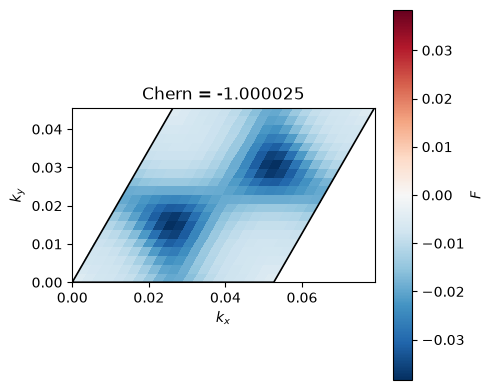

In [275]:
"""计算第一价带的陈数"""
"""现在不用六角形miniBZ，换成一个平行四边形区域计算微元上的曲率"""
"""F^hatsugai_kx_ky = arg(<u_k|u_k+dkx> * <u_k+dkx|u_k+dkx+dky> * <u_dkx+dky|u_k+dky> * <u_dky|u_k>)"""

def calc_chern (bx, by, step, band_id):
    dbx = bx/step
    dby = by/step
    
    vecs = np.zeros((step+1, step+1, dim), dtype = complex)
    eband = np.zeros((step+1, step+1))
    for i in tqdm.tqdm(range(0,step+1)):
        for j in range(0,step+1):
            k = i * dbx + j * dby
            H0tot = H0_non_diag + calc_H0_diag(k, Gs, Kt, Kb)
            e , v = np.linalg.eigh(H0tot)
            vecs[i,j,:] = v[:,band_id]
            eband[i,j] = e[band_id]
    
    F = np.zeros((step,step))
    for i in range(0,step):
        for j in range(0,step):
            vs = [vecs[i,j,:], vecs[i+1,j,:],vecs[i+1,j+1,:],vecs[i,j+1,:]]   
            ua = np.vdot(vs[0],vs[1]) 
            ub = np.vdot(vs[1],vs[2])
            uc = np.vdot(vs[2],vs[3])
            ud = np.vdot(vs[3],vs[0])
            Zi = ua*ub*uc*ud
            F[i,j] = np.angle(Zi)
    return F

def plot_F(F, b0, b1, step):
    b0 = np.asarray(b0, dtype=float).reshape(2)
    b1 = np.asarray(b1, dtype=float).reshape(2)
    I, J = np.meshgrid(np.arange(step + 1), np.arange(step + 1), indexing='ij')
    X = I * (b0[0] / step) + J * (b1[0] / step)
    Y = I * (b0[1] / step) + J * (b1[1] / step)

    vmax = np.abs(F).max() or 1.0

    fig, ax = plt.subplots(figsize=(5, 4))
    mesh = ax.pcolormesh(X, Y, F.T, cmap='RdBu_r',
                         vmin=-vmax, vmax=vmax, shading='flat')

    # BZ 边界
    corners = np.array([[0, 0], b0, b0 + b1, b1, [0, 0]])
    ax.plot(corners[:, 0], corners[:, 1], 'k-', lw=1.2)

    fig.colorbar(mesh, ax=ax, label=r'$F$')
    ax.set_aspect('equal')
    ax.set_xlabel(r'$k_x$'); ax.set_ylabel(r'$k_y$')
    ax.set_title(f'Chern = {F.sum()/(2*np.pi):.6f}')
    plt.tight_layout(); plt.show()

step = 20
band_id = -2
F = calc_chern(b[0], b[1], step, band_id)
ch = np.sum(F[:step, :step]) / (2 * np.pi)
print(f"chern_number {ch:.5f} band {band_id}")
plot_F(F,b[0],b[1], step)

##  H0的周期性 ##

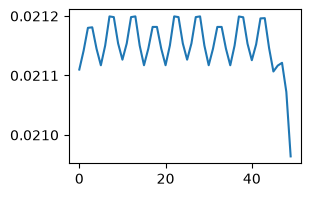

In [60]:
"""验证哈密顿量沿着某个方向在某个范围是否有周期性"""
path = kpoints(-5*KK,5*KK,50)
etot = []
for  i,k in enumerate(path):
    H0 = H0_non_diag + calc_H0_diag(k, Gs, Kt, Kb)
    e,v = np.linalg.eigh(H0)
    etot.append(e[-1])

plt.figure(figsize=(3, 2))
plt.plot(etot)

##  相互作用投影与ED ##

In [263]:
"""
沿着实空间基矢量L0和L1方向复制N*M次形成原胞cluster(N*M个原胞组成的平行四边形)，
这等价于在mini BZ中采样N*M个动量点，用mBZ的六角形区域模出来N*M个采样点。

实空间上的库仑相互作用V翻译到动量空间的一个矩阵元就是sum_{q} { V<k1|exp(iq*r1)|k3> <k2|exp(i(-q)*r2)|k4> } ，
一个电子在r1处和另一个电子在r2处交换了一个动量q。

由于我们的单粒子哈密顿量用的是截断的平面波基矢量因此动量q包含了两部分，
一部分是mBZ中采样点之间交换的小动量部分 [q]，另一部分是mBZ的晶格动量G，q = [q]+G，
[q]可以看成动量q模掉整数个mBZ晶格动量G后到mBZ的余数。

矩阵元可以写成sum_{q} { {V(q)} * {delta_{k1,k3+[q]} delta_{k2,k4-[q]}} * F(k1,k3,G_{k3+q}) * F(k2,k4, G_{k4-q}) }
delta函数直接翻译了<k1|exp(i[q]*r)|k3>矩阵元的小动量部分，q的晶格部分(G_{k3+q}) (因为exp(iq*r)|k3>作用给出k3+q这个因子)包含在形状因子F中，
所以F = sum_{G'}u*_{k1,G_{k3+q} + G'} u_{k3,G'} 这里的u_{k,G}是单粒子波函数在k采样点的G分量的系数，这个求和的包含了所有从G'传递G'+G_{k3+q}的情况的振幅
"""
N1 = 4 #实空间30°方向的原胞数量
N2 = 6 #实空间-90°方向的原胞数量
N = N1*N2 #总采样数量
nu = 1/3
Ne = int(np.round(N * nu))
band_id = -1 #chern带标记

In [264]:
cons_U = 1.38e-3/N *4 *np.pi/np.sqrt(3)

"""生成采样点"""
bias_x = 0
bias_y = 0
ks = np.array([(i+bias_x)*b[0]/N1 + (j+bias_y)*b[2]/N2 for i in range(0,N1) for j in range(0,N2)])
kmesh = ks
kmesh = np.array(kmesh)
assert len(kmesh) == N #检查生成的采样点数量

"""计算每个k采样点上的单粒子波函数"""
kvecs = np.zeros((N, dim), dtype = complex)#每个采样点存一个波函数向量
keigs = np.zeros(N) #每个采样点的能量本征值
for i,k in enumerate(kmesh):
    H0 = H0_non_diag+ calc_H0_diag(k,Gs,Kt,Kb)
    eig, eigvec = np.linalg.eigh(H0)
    kvecs[i,:] = eigvec[:,band_id]
    keigs[i] = eig[band_id]

"""计算库伦相互作用矩阵元"""
def calc_cons_q(q):
    q = np.linalg.norm(q)
    #绕过电导率的计算
    t = q * aM
    if t > 3:
        tt = 1
    else:   
        tt = t * (27 + t * t) / (27 + 9 * t * t)  
    cons = cons_U * tt/t
    return cons
    
#晶格动量的转移可以是两个对角格点相减，因此会是2倍大小的Gs
Gs = np.array([m*b[0] + n*b[2] for m in range(-Nbloch, Nbloch+1) for n in range(-Nbloch, Nbloch+1)])
G_coord_ext = np.array([(m,n) for m in range(-2*Nbloch, 2*Nbloch+1) for n in range(-2*Nbloch, 2*Nbloch+1)])
Gs_ext = np.array([m*b[0] + n*b[2] for m in range(-2*Nbloch, 2*Nbloch+1) for n in range(-2*Nbloch, 2*Nbloch+1)])
A = A_cell * N

def calc_interaction(kvecs,i,j,k,l):
    #限制q在一个mBZ中，如果q匹配成功，那么遍历所有的G,去匹配G
    # i -> k 匹配 j -> l
    k1 = kmesh[i]
    k2 = kmesh[j]
    k3 = kmesh[k]
    k4 = kmesh[l]
    if np.linalg.norm((k1 - k3) - (k4 - k2)) < 1e-8 and np.linalg.norm(k1 - k3) > 1e-8:
        #遍历所有的截断晶格向量
        V_int = 0
        for g_coord in G_coord_ext:
            g = g_coord[0]*b[0] + g_coord[1]*b[1]
            #cons_q = cons/np.linalg.norm(k1 - k3 + g) #转移动量包含mBZ内部的小动量和大晶格动量g
            F1 = calc_form_factor(kvecs[i,:],kvecs[k,:], g_coord)
            F2 = calc_form_factor(kvecs[j,:],kvecs[l,:], -g_coord)
            V_int += calc_cons_q(k1 - k3 + g) * F1 * F2
        return V_int
    else:
        return 0

def coord_to_index(x,y):
    idx = Nbloch*(x+Nbloch) + y+Nbloch
    return idx
    
def calc_form_factor(vec1,vec2,g_coord):
    #form factor需要按照层内匹配去计算
    x1 = max([-Nbloch + g_coord[0] , -Nbloch])
    x2 = min([+Nbloch + g_coord[0] , +Nbloch])
    y1 = max([-Nbloch + g_coord[1] , -Nbloch])
    y2 = min([+Nbloch + g_coord[1] , +Nbloch])
    
    ff = 0
    for xi in range(x1,x2+1):
        for yi in range(y1,y2+1):
            ff += vec1[coord_to_index(xi,yi)].conj() * vec2[coord_to_index(xi,yi)] #top 层
            ff +=vec1[coord_to_index(xi,yi)+(2*Nbloch+1)**2].conj() * vec2[coord_to_index(xi,yi)+(2*Nbloch+1)**2] #bottom层
    return ff

"""记录所有的交换动量匹配的4点矩阵元"""
"""规定产生算符是按照升序序号排列，湮灭算符是按照降序序号排列"""
""" i -> k j -> l，i,j是需要湮灭的占据，k,l是产生的占据"""
""" +V -> (l < k, i > j)"""
V_pairs = []
for i in tqdm.tqdm(range(1,N)):
    for j in range(0,i):
        #这里只规定ij的降序顺序
        for k in range(0,N):
            for l in range(0,N):
                if (l == k) or (l ==j) or (l == i) or (k == i) or (k == j) :
                    continue
                v = calc_interaction(kvecs,i,j,k,l)
                if k > j:
                    V_pairs.append([v,i,j,k,l]) #i -> k j ->l
                else:
                    V_pairs.append([-v,i,j,k,l]) # k< l就是在挖掉ij的态上先生成左边的k再生成右边的l，l要越过k出现负号


100%|██████████| 23/23 [21:05<00:00, 55.02s/it]


In [ ]:
def save_V(V_pairs):
    V_vals = np.array([v[0] for v in V_pairs], dtype=np.complex128)  
    V_indx = np.array([v[1:] for v in V_pairs], dtype=np.int32)     
    np.savez('V_pairs.npz', V_vals = V_vals, V_indx = V_indx)

def load_V():
    data = np.load('V_pairs.npz')
    V_vals = data['V_vals']      # complex128
    V_indx = data['V_indx']    # int32
    V_pairs = [ [V_vals[i], int(V_indx[i, 0]), int(V_indx[i, 1]), int(V_indx[i, 2]), int(V_indx[i, 3])] for i in range(len(V_vals)) ]
    return V_pairs

In [156]:
save_V(V_pairs)

### 直接对角化哈密顿量 ###

In [34]:
"""生成fock space，直接对角化"""
basis = spinless_fermion_basis_1d(L=N, Nf=Ne)
print("basis dimension:", basis.Ns)  
Hb_int = [["++--", V_pairs]]
Hb_H0 = [["n", [[keigs[k], k] for k in range(N)]]]
Hb_total = Hb_H0 + Hb_int
H = hamiltonian(Hb_total, [], basis=basis, dtype=np.complex128, check_herm=False)
print("H shape:", H.shape)
tot = H.shape[0] * H.shape[1]
print(H.static.nnz / tot)#统计一下矩阵的稀疏度
nze = H.static.tocoo()#所有非零元素

#厄密化哈密顿量
"""
for i,j in zip(nze.row, nze.col):
    if j > i:
        re = (H.static[i,j].real + H.static[j,i].real)/2
        reres = (H.static[i,j].real - H.static[j,i].real)
        im = (H.static[i,j].imag - H.static[j,i].imag)/2
        imres = (H.static[i,j].imag + H.static[j,i].imag)
        H.static[i,j] = re + 1j*im
        H.static[j,i] = re - 1j*im
"""
eigvals, eigvecs = H.eigh() #H.eigsh(k=200, which="SA") #只求解低能的本征值
E_gs = eigvals[0]
eigvals0 = (eigvals-E_gs) * 1000 #转换为meV
print(eigvals0[0:20])
np.savez('eig_result.npz', eigvals=eigvals0, eigvecs=eigvecs)

basis dimension: 84
Symmetry checks passed!
Particle conservation check passed!
H shape: (84, 84)
0.04308390022675737
[ 0.          1.19964522  5.19159381  6.87628687  7.89541245  8.42056206
  8.6719908   9.28143668 10.17695276 10.54419372 10.85319392 10.90521905
 11.30712117 11.43091698 11.68620979 11.85590926 12.28187752 12.31732239
 12.39964158 12.4020219 ]


100%|██████████| 495/495 [00:40<00:00, 12.10it/s]


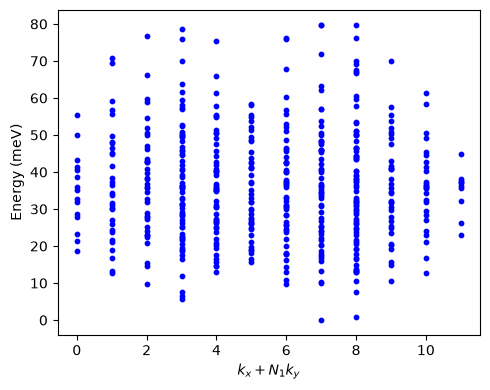

In [10]:
r = np.arange(N1)
q = np.arange(N2)
N = N1*N2
k_table = np.array([(x,y) for y in q for x in r])

#一个态|k0.....k_N>所有占据位数的总动量和总能量，以格点坐标的形式记录
def state_to_coord(idx):
    coord = 0
    epsilon = 0
    for j in range(N):
        bit = ((idx >> j) & 1)
        coord +=  bit * k_table[N-j-1]
    return (coord[0] % N1, coord[1] % N2)

def calc_eig_momentum(v):
    kexp = 0
    for i in range(basis.Ns):
        state = basis.states[i]
        coord = state_to_coord(state)
        #coord_str = basis.int_to_state(state)
        density = np.linalg.norm(v[i]) ** 2
        kexp += density * np.array(coord)
    return [round(kexp[0]),round(kexp[1])]
    
def plot_spectrum(eigvals,eigvecs):
    points = []
    for i in tqdm.tqdm(range(len(eigvals))):
        k = calc_eig_momentum(eigvecs[:,i])
        k_linear = k[0] + N1 * k[1] 
        points.append((k_linear,eigvals[i]))
    points = np.array(points)
    
    k_vals = points[:, 0]
    E_vals = points[:, 1] 
    plt.figure(figsize=(5, 4))
    plt.scatter(k_vals, E_vals, s=10, c='b')
    plt.xlabel(r'$k_x + N_1 k_y$')
    plt.ylabel('Energy (meV)')
    plt.tight_layout()
    plt.show()

plot_spectrum(eigvals0,eigvecs)

### 分块对角化加速 ###

In [265]:
basis = spinless_fermion_basis_1d(L=N, Nf=Ne)
print("basis dimension:", basis.Ns)  

r = np.arange(N1)
q = np.arange(N2)
N = N1*N2
k_table = np.array([(x,y) for y in q for x in r])
klen = len(k_table)
E_table = keigs

def state_to_eig(idx):
    e = 0
    for j in range(N):
        bit = ((idx >> j) & 1)
        e +=  bit * E_table[N-j-1]
    return e
    
def state_to_coord(idx):
    coord = 0
    for j in range(N):
        bit = ((idx >> j) & 1)
        coord +=  bit * k_table[N-j-1]
    return (coord[0] % N1, coord[1] % N2)

#tags[i] 记录了K=i的所有态的集合
tags = []
for i in range(klen):
    tags.append([])

#对basis的总动量分类
for i in tqdm.tqdm(range(basis.Ns)):
    st = basis.states[i]
    coord = state_to_coord(st)
    coord_l = coord[0] + N1 * coord[1]
    tags[coord_l].append(st)

basis dimension: 735471


100%|██████████| 735471/735471 [02:58<00:00, 4110.28it/s]


V_pairs:127512


100%|██████████| 24/24 [4:02:07<00:00, 605.31s/it]  


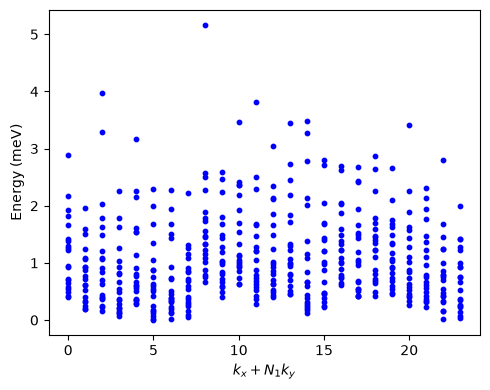

In [268]:
#V_array记录所有形如 cl+ck+ci-cj-的相互作用算符 i>j 用来查找
#V_dict用来快速查找符合的形状
V_dict = {} 
V_array = np.zeros((N, N, N, N), dtype=np.complex128)
print(f"V_pairs:{len(V_pairs)}")
for V, i, j, k, l in tqdm.tqdm(V_pairs):
    V_array[i, j, k, l] = V
    V_dict[((1 << i) | (1 << j) | (1 << k) | (1 << l))] = 1

#对于某一个block K=i，两两态之间做xor
#Block_V = np.zeros((len(tags[0]), len(tags[0])),dtype = np.complex128)
eigs_tot = []
for i in tqdm.tqdm(range(klen)):
    rows = []
    cols = []
    data = []
    #print(f"momentum:{i} dim:{len(tags[i])}")

    t00 = time.perf_counter()
    for p in range(len(tags[i])):
        
        #对角项
        E = state_to_eig(tags[i][p])
        rows.append(p)
        cols.append(p)
        data.append(E)
        
        for q in range(0,p):
            x = tags[i][p] ^ tags[i][q]
            if x.bit_count() == 4 and V_dict.get(x,0):
                t1 = []
                t2 = []
                for t in range(N):
                    tt = (1 << t)
                    if (tt & tags[i][p]) and ((tt & tags[i][q]) ==0) :
                        t1.append(N-1-t) #t1[1] 是 j t1[0] 是 i
                    if (tt & tags[i][q]) and ((tt & tags[i][p]) ==0):
                        t2.append(N-1-t)
                z = ((p << (t1[1]+1)) >>(t1[1]+1+N-t1[0])).bit_count()+((p << (t2[1]+1)) >> (t2[1]+1+N-t2[0])).bit_count()
                z = (-1)**z
                rows.append(p)
                cols.append(q)
                #ij->kl如果合法，那么ij->lk也合法。我在V_pair时已经规定l<k为正序，V_pair中的符号已经是正确的了
                data.append( z * (V_array[t1[0],t1[1],t2[0],t2[1]] + V_array[t1[0],t1[1],t2[1],t2[0]]))
    t0 = time.perf_counter()
    
    sps = coo_matrix((data, (rows, cols)), shape=(len(tags[i]), len(tags[i])))
    sps = sps + sps.getH()
    t1 = time.perf_counter()
    #print(f"Coo time:{t1-t0:.1f}")
    eigs, _ = eigsh(sps, k=20, which='LM')
    t2 = time.perf_counter()
    #print(f"Eig time:{t2-t0:.1f}")
    eigs_tot.append(eigs)
    #print(eigs*1000)

def plot_spetrum_block(es):
    points = []
    for i in range(len(es)):
        for j in range(len(es[i])):
            points.append((i,es[i][j]))
    Emin = min(j for _, j in points)
    points = np.array(points)
    
    k_vals = points[:, 0]
    E_vals = (points[:, 1] - Emin)*1000
    plt.figure(figsize=(5, 4))
    plt.scatter(k_vals, E_vals, s=10, c='b')
    plt.xlabel(r'$k_x + N_1 k_y$')
    plt.ylabel('Energy (meV)')
    plt.tight_layout()
    plt.show()
    
plot_spetrum_block(eigs_tot)

In [269]:
es = []
for i  in range(len(eigs_tot)):
    for j in range(len(eigs_tot[i])):
        es.append(eigs_tot[i][j])
es = np.array(es)
es = (es - es.min())*1000

es.sort()

In [271]:
np.savez('Grid_4x6.npz', Nlobch = Nbloch, nu = nu, eigs = eigs_tot)